# Expected Number of Bets (ENB) Analysis

This notebook analyzes the ENB/N metric across subsets of the JPM and HFR datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-whitegrid')

/opt/anaconda3/envs/investmentepfl/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the data
df_jpm = pd.read_csv('data/time_series_jpm_renamed.csv', index_col=0, parse_dates=True)
df_hfr = pd.read_csv('data/HFR_2000.csv', index_col=0, parse_dates=True)

# Trim the data to span from 2020 to the end of 2025
start_date = '2020-01-01'
end_date = '2025-12-31'
df_jpm_trimmed = df_jpm.loc[start_date:end_date]
df_hfr_trimmed = df_hfr.loc[start_date:end_date]

# Drop funds that do not have a full track record in this period
df_jpm_clean = df_jpm_trimmed.dropna(axis=1, how='any')
df_hfr_clean = df_hfr_trimmed.dropna(axis=1, how='any')

# Filter out funds that have 0.0 return for more than 10% of the time
jpm_zero_counts = (df_jpm_clean == 0.0).sum(axis=0)
jpm_valid_funds = jpm_zero_counts[jpm_zero_counts < (len(df_jpm_clean) * 0.1)].index
df_jpm_clean = df_jpm_clean[jpm_valid_funds]

hfr_zero_counts = (df_hfr_clean == 0.0).sum(axis=0)
hfr_valid_funds = hfr_zero_counts[hfr_zero_counts < (len(df_hfr_clean) * 0.1)].index
df_hfr_clean = df_hfr_clean[hfr_valid_funds]

print(f"JPM funds with complete track records: {df_jpm_clean.shape[1]}")
print(f"HFR funds with complete track records: {df_hfr_clean.shape[1]}")

JPM funds with complete track records: 347
HFR funds with complete track records: 354


In [3]:
def compute_enb_standardized(returns):
    n = returns.shape[1]
    if n == 0:
        return np.nan
        
    corr_matrix = returns.corr().fillna(0)
    eigenvalues = np.linalg.eigvals(corr_matrix)
    eigenvalues = np.real(eigenvalues)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[eigenvalues > 1e-8]
    
    if len(eigenvalues) == 0:
        return 1.0 / n
        
    enb = (np.sum(eigenvalues) ** 2) / np.sum(eigenvalues ** 2)
    return enb / n

In [4]:
def bootstrap_worker_enb(data_df, n):
    cols = data_df.columns.tolist()
    sel = np.random.choice(cols, size=n, replace=False)
    returns_subset = data_df[sel]
    return compute_enb_standardized(returns_subset)

def run_bootstrap_enb_n(data_df, n, n_boot=1000):
    res = []
    if len(data_df.columns) < n:
        return []
        
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(bootstrap_worker_enb, data_df, n) for _ in range(n_boot)]
        for future in tqdm(as_completed(futures), total=n_boot, desc=f"Bootstrap ENB n={n}", leave=False):
            res.append(future.result())
            
    return res

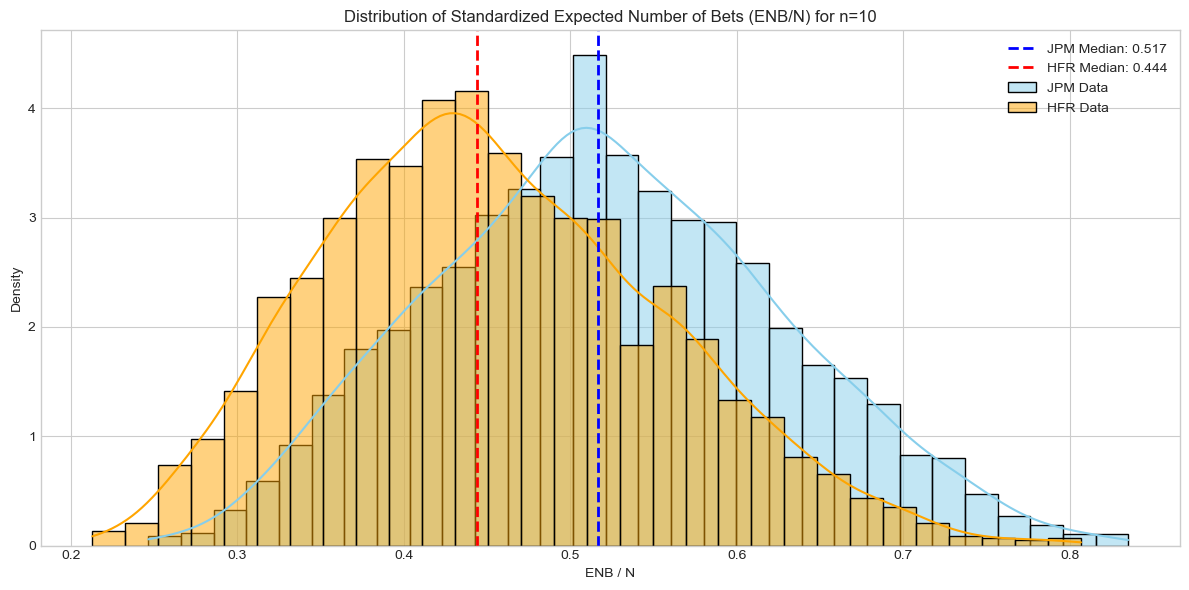

In [5]:
# Plot distributions for n=10
np.random.seed(42)
n_val = 10
enb_jpm_10 = run_bootstrap_enb_n(df_jpm_clean, n_val, n_boot=3000)
enb_hfr_10 = run_bootstrap_enb_n(df_hfr_clean, n_val, n_boot=3000)

plt.figure(figsize=(12, 6))
sns.histplot(enb_jpm_10, bins=30, color='skyblue', label='JPM Data', kde=True, stat='density', alpha=0.5)
sns.histplot(enb_hfr_10, bins=30, color='orange', label='HFR Data', kde=True, stat='density', alpha=0.5)

plt.axvline(np.median(enb_jpm_10), color='blue', linestyle='dashed', linewidth=2, label=f'JPM Median: {np.median(enb_jpm_10):.3f}')
plt.axvline(np.median(enb_hfr_10), color='red', linestyle='dashed', linewidth=2, label=f'HFR Median: {np.median(enb_hfr_10):.3f}')

plt.title(f'Distribution of Standardized Expected Number of Bets (ENB/N) for n={n_val}')
plt.xlabel('ENB / N')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def run_scaling_analysis_enb(jpm_data, hfr_data, n_boot=1000):
    n_values = range(3, 21)
    results_jpm = {'median': [], 'q1': [], 'q3': []}
    results_hfr = {'median': [], 'q1': [], 'q3': []}
    
    for n in tqdm(n_values, desc="Scaling sizes"):
        res_jpm = run_bootstrap_enb_n(jpm_data, n, n_boot)
        res_hfr = run_bootstrap_enb_n(hfr_data, n, n_boot)
        
        results_jpm['median'].append(np.median(res_jpm))
        results_jpm['q1'].append(np.percentile(res_jpm, 25))
        results_jpm['q3'].append(np.percentile(res_jpm, 75))
        
        results_hfr['median'].append(np.median(res_hfr))
        results_hfr['q1'].append(np.percentile(res_hfr, 25))
        results_hfr['q3'].append(np.percentile(res_hfr, 75))
        
    return pd.DataFrame(results_jpm, index=n_values), pd.DataFrame(results_hfr, index=n_values)

# Run the scaling analysis
np.random.seed(42)
df_scaling_jpm, df_scaling_hfr = run_scaling_analysis_enb(df_jpm_clean, df_hfr_clean, n_boot=1000)

Scaling sizes: 100%|██████████| 18/18 [00:08<00:00,  2.17it/s]


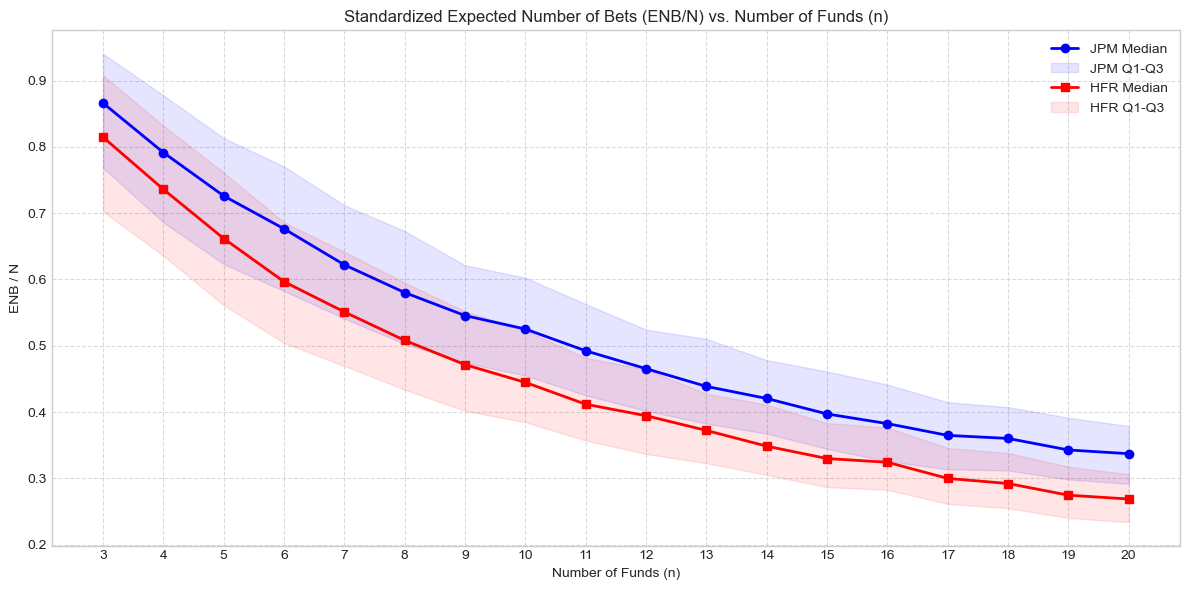

In [7]:
# Plot scaling analysis
plt.figure(figsize=(12, 6))

# Plot JPM
plt.plot(df_scaling_jpm.index, df_scaling_jpm['median'], marker='o', linestyle='-', color='blue', linewidth=2, label='JPM Median')
plt.fill_between(df_scaling_jpm.index, df_scaling_jpm['q1'], df_scaling_jpm['q3'], color='blue', alpha=0.1, label='JPM Q1-Q3')

# Plot HFR
plt.plot(df_scaling_hfr.index, df_scaling_hfr['median'], marker='s', linestyle='-', color='red', linewidth=2, label='HFR Median')
plt.fill_between(df_scaling_hfr.index, df_scaling_hfr['q1'], df_scaling_hfr['q3'], color='red', alpha=0.1, label='HFR Q1-Q3')

plt.title('Standardized Expected Number of Bets (ENB/N) vs. Number of Funds (n)')
plt.xlabel('Number of Funds (n)')
plt.ylabel('ENB / N')
plt.xticks(list(range(3, 21)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()